In [18]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [6]:
X,y = make_blobs(n_samples=1000, centers=3,n_features=2)

In [7]:
X

array([[ 8.07310158,  0.92947929],
       [ 6.88074878,  0.62208229],
       [ 8.2143521 ,  1.3338457 ],
       ...,
       [-7.52560478,  8.33429614],
       [ 0.92345867, -2.88882439],
       [ 6.28585372,  0.62599179]], shape=(1000, 2))

In [8]:
y

array([2, 2, 2, 0, 2, 1, 0, 0, 1, 2, 0, 0, 0, 1, 2, 2, 0, 1, 1, 2, 1, 0,
       2, 0, 2, 2, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 2, 1, 0, 1,
       1, 0, 0, 1, 2, 1, 1, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 1, 2, 0, 2, 0,
       0, 2, 1, 1, 0, 1, 2, 1, 2, 2, 2, 1, 1, 2, 2, 1, 0, 1, 1, 1, 0, 2,
       0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 2, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 2, 1, 1, 2, 2, 0, 2, 1, 2, 1, 0, 2, 1, 2, 0, 2,
       2, 1, 0, 2, 1, 2, 1, 2, 1, 2, 2, 0, 2, 2, 2, 0, 0, 0, 0, 2, 0, 1,
       0, 2, 0, 0, 1, 0, 2, 1, 0, 1, 1, 1, 1, 1, 2, 0, 1, 1, 1, 2, 2, 2,
       2, 0, 2, 1, 2, 0, 0, 0, 0, 0, 2, 1, 0, 0, 0, 1, 0, 0, 2, 1, 1, 1,
       0, 2, 1, 0, 1, 1, 1, 2, 0, 2, 0, 2, 0, 1, 1, 0, 1, 0, 0, 2, 2, 0,
       2, 0, 0, 1, 0, 0, 0, 1, 0, 2, 0, 0, 1, 0, 1, 2, 2, 0, 2, 0, 0, 2,
       2, 1, 2, 2, 2, 1, 2, 1, 2, 0, 0, 0, 1, 0, 2, 0, 2, 1, 0, 2, 2, 1,
       0, 0, 2, 1, 2, 2, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 2, 0, 2, 0, 0, 0,
       2, 1, 0, 0, 2, 0, 1, 0, 2, 2, 1, 2, 2, 2, 1,

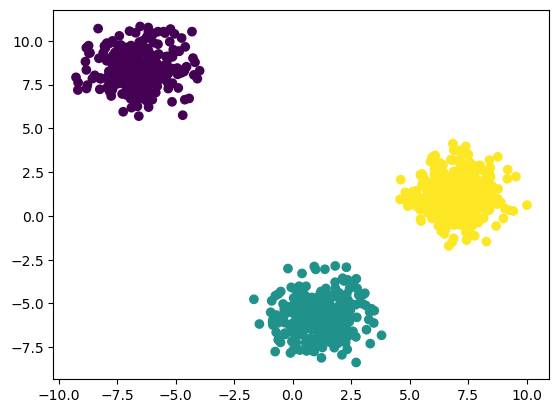

In [9]:
plt.scatter(X[:,0],X[:,1],c=y)

In [10]:
## standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [15]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.cluster import KMeans

In [21]:
## Elbow method To select K Value
wcss = []
for k in range(1,16):
    kmeans = KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [22]:
wcss

[1340.0000000000005,
 318.6202371915762,
 41.42065413874968,
 37.011138848646866,
 31.33467321005146,
 27.385638326194766,
 24.702668257865874,
 21.462012955827092,
 18.414015818213677,
 16.598667181319684,
 15.442979346549564,
 15.256857143673033,
 13.401507169062924,
 12.58884739272194,
 11.486552372072714]

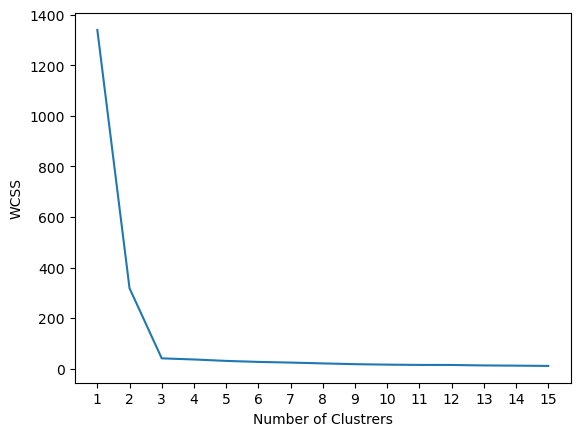

In [23]:
## plot elbow curve
plt.plot(range(1,16),wcss)
plt.xticks(range(1,16))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [24]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [25]:
kmeans.fit_predict(X_train_scaled)

array([1, 1, 2, 2, 2, 0, 0, 1, 2, 1, 0, 1, 0, 0, 1, 2, 1, 0, 2, 2, 1, 2,
       0, 0, 1, 2, 0, 1, 2, 2, 1, 2, 2, 2, 0, 0, 0, 1, 0, 2, 1, 0, 0, 2,
       1, 0, 1, 0, 0, 1, 2, 2, 1, 0, 2, 0, 1, 2, 1, 1, 1, 0, 0, 1, 1, 2,
       2, 2, 0, 1, 2, 2, 0, 1, 0, 0, 2, 0, 1, 0, 1, 2, 0, 1, 0, 2, 0, 1,
       2, 0, 0, 1, 0, 2, 0, 2, 0, 0, 1, 0, 1, 2, 2, 0, 2, 1, 1, 2, 2, 2,
       0, 1, 2, 2, 1, 2, 1, 2, 1, 1, 0, 1, 2, 0, 2, 2, 1, 0, 0, 0, 2, 0,
       0, 1, 2, 0, 1, 2, 0, 0, 0, 1, 1, 1, 1, 0, 2, 0, 2, 2, 2, 1, 1, 2,
       1, 0, 1, 0, 0, 0, 1, 1, 2, 1, 2, 2, 2, 0, 2, 1, 2, 1, 2, 2, 1, 0,
       0, 1, 1, 1, 1, 0, 2, 2, 0, 2, 1, 0, 0, 2, 2, 0, 2, 0, 0, 0, 0, 0,
       1, 1, 2, 0, 2, 1, 0, 2, 0, 2, 1, 1, 1, 2, 2, 1, 0, 1, 0, 2, 1, 1,
       2, 2, 0, 0, 0, 0, 1, 2, 1, 1, 0, 2, 2, 1, 0, 2, 2, 1, 2, 2, 1, 2,
       2, 0, 0, 2, 2, 1, 1, 0, 0, 2, 2, 2, 0, 2, 1, 2, 2, 2, 2, 0, 1, 0,
       1, 1, 0, 1, 0, 2, 0, 2, 2, 1, 0, 0, 1, 0, 2, 0, 2, 1, 1, 1, 0, 2,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 2, 2, 0, 2, 1,

In [26]:
y_pred=kmeans.predict(X_test_scaled)

In [27]:
y_pred

array([0, 0, 1, 0, 2, 1, 1, 1, 0, 0, 0, 2, 1, 2, 0, 1, 2, 2, 0, 1, 1, 2,
       2, 0, 1, 2, 1, 0, 0, 1, 1, 2, 0, 0, 1, 1, 0, 1, 2, 2, 0, 1, 2, 0,
       2, 2, 1, 1, 2, 0, 0, 2, 2, 2, 1, 1, 0, 1, 1, 1, 0, 2, 0, 2, 1, 2,
       1, 0, 1, 2, 1, 0, 0, 1, 0, 1, 0, 1, 2, 1, 2, 1, 1, 2, 1, 2, 0, 0,
       2, 0, 1, 0, 2, 2, 2, 2, 2, 1, 1, 2, 1, 1, 0, 2, 0, 2, 0, 1, 2, 0,
       1, 2, 1, 2, 1, 1, 1, 2, 1, 2, 1, 0, 0, 1, 1, 1, 0, 2, 2, 0, 2, 1,
       1, 0, 1, 2, 2, 1, 2, 2, 0, 0, 2, 1, 0, 2, 0, 2, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 1, 0, 2, 1, 0, 2, 2, 1, 0, 0, 0, 0,
       0, 0, 2, 1, 2, 2, 0, 2, 2, 2, 2, 1, 2, 1, 2, 0, 2, 2, 1, 1, 0, 1,
       2, 0, 1, 1, 2, 1, 1, 0, 0, 1, 0, 1, 1, 2, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 1, 0, 2, 1, 2, 0, 2, 2, 1, 1, 1, 1, 1, 2, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 2, 1, 0, 0, 2, 1, 0, 0, 2, 1, 0, 0, 2, 1, 2,
       1, 0, 2, 0, 0, 1, 1, 0, 0, 2, 2, 2, 0, 0, 0, 2, 1, 2, 1, 2, 0, 2,
       2, 2, 0, 2, 1, 0, 1, 1, 2, 0, 0, 2, 1, 2, 1,

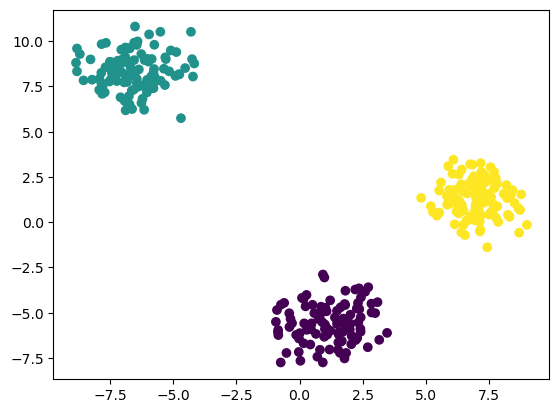

In [28]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [ ]:
## Validating the k value
## kneelocator
## Silhoutee scoring

In [30]:
## kneelocator
%pip install kneed

Note: you may need to restart the kernel to use updated packages.


In [31]:
from kneed import KneeLocator

In [33]:
kl=KneeLocator(range(1,16),wcss,curve="convex",direction="decreasing")

In [35]:
kl.elbow

np.int64(3)

In [36]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [37]:
silhouette_coefficients=[]
for k in range(2,16):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [38]:
silhouette_coefficients

[0.7304589392550687,
 0.8273002595676512,
 0.6558715920315138,
 0.49012758709695337,
 0.5026349728096194,
 0.5125327377083935,
 0.3429240268318612,
 0.3227770953448427,
 0.3484787806630239,
 0.3367927322294983,
 0.3381437798213287,
 0.3138809530119281,
 0.32582113902741233,
 0.3243549061725926]

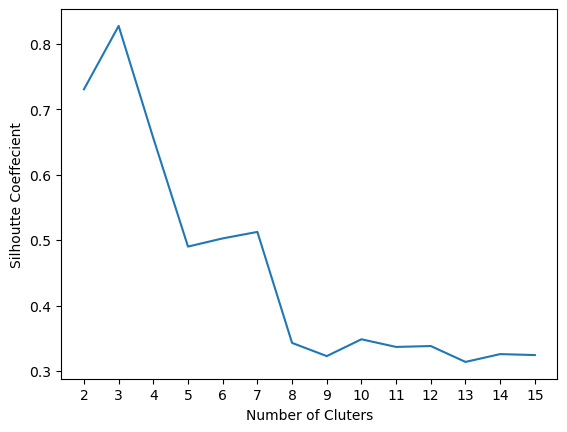

In [40]:
## plotting silhouette score
plt.plot(range(2,16),silhouette_coefficients)
plt.xticks(range(2,16))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()